In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df = pd.read_csv("HousePriceDataset.csv")

In [8]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,LocationScore,Price
0,1660,1,2,2,2010,1,3,3.697582e+05
1,4572,5,3,2,1951,1,7,1.011358e+06
2,3892,4,1,1,1982,0,4,8.422723e+05
3,1266,1,2,2,2021,0,10,2.886733e+05
4,4244,4,3,2,2011,0,7,8.524454e+05


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area           5000 non-null   int64  
 1   Bedrooms       5000 non-null   int64  
 2   Bathrooms      5000 non-null   int64  
 3   Floors         5000 non-null   int64  
 4   YearBuilt      5000 non-null   int64  
 5   Garage         5000 non-null   int64  
 6   LocationScore  5000 non-null   int64  
 7   Price          5000 non-null   float64
dtypes: float64(1), int64(7)
memory usage: 312.6 KB


In [10]:
df.shape

(5000, 8)

In [11]:
print(df.isnull().sum())

Area             0
Bedrooms         0
Bathrooms        0
Floors           0
YearBuilt        0
Garage           0
LocationScore    0
Price            0
dtype: int64


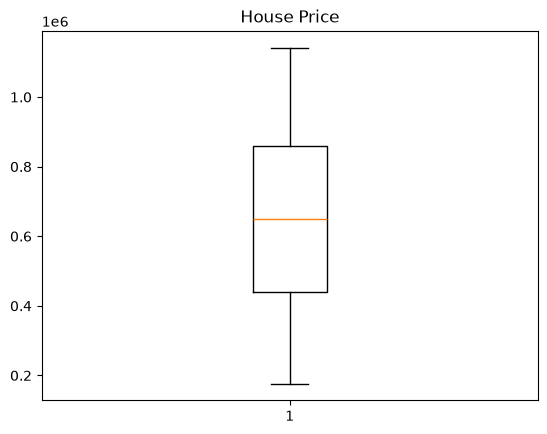

In [12]:
plt.boxplot(df["Price"])
plt.title("House Price")
plt.show()

In [13]:
x = df.drop("Price", axis = 1)
y = df["Price"]

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

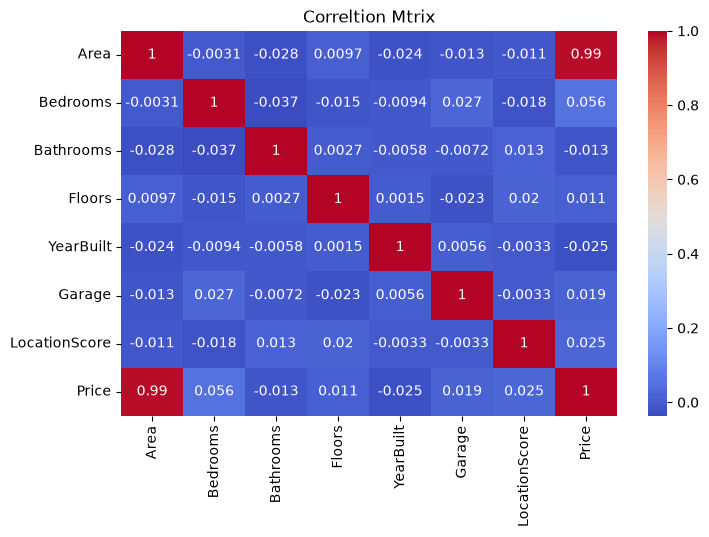

In [16]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correltion Mtrix")
plt.show()

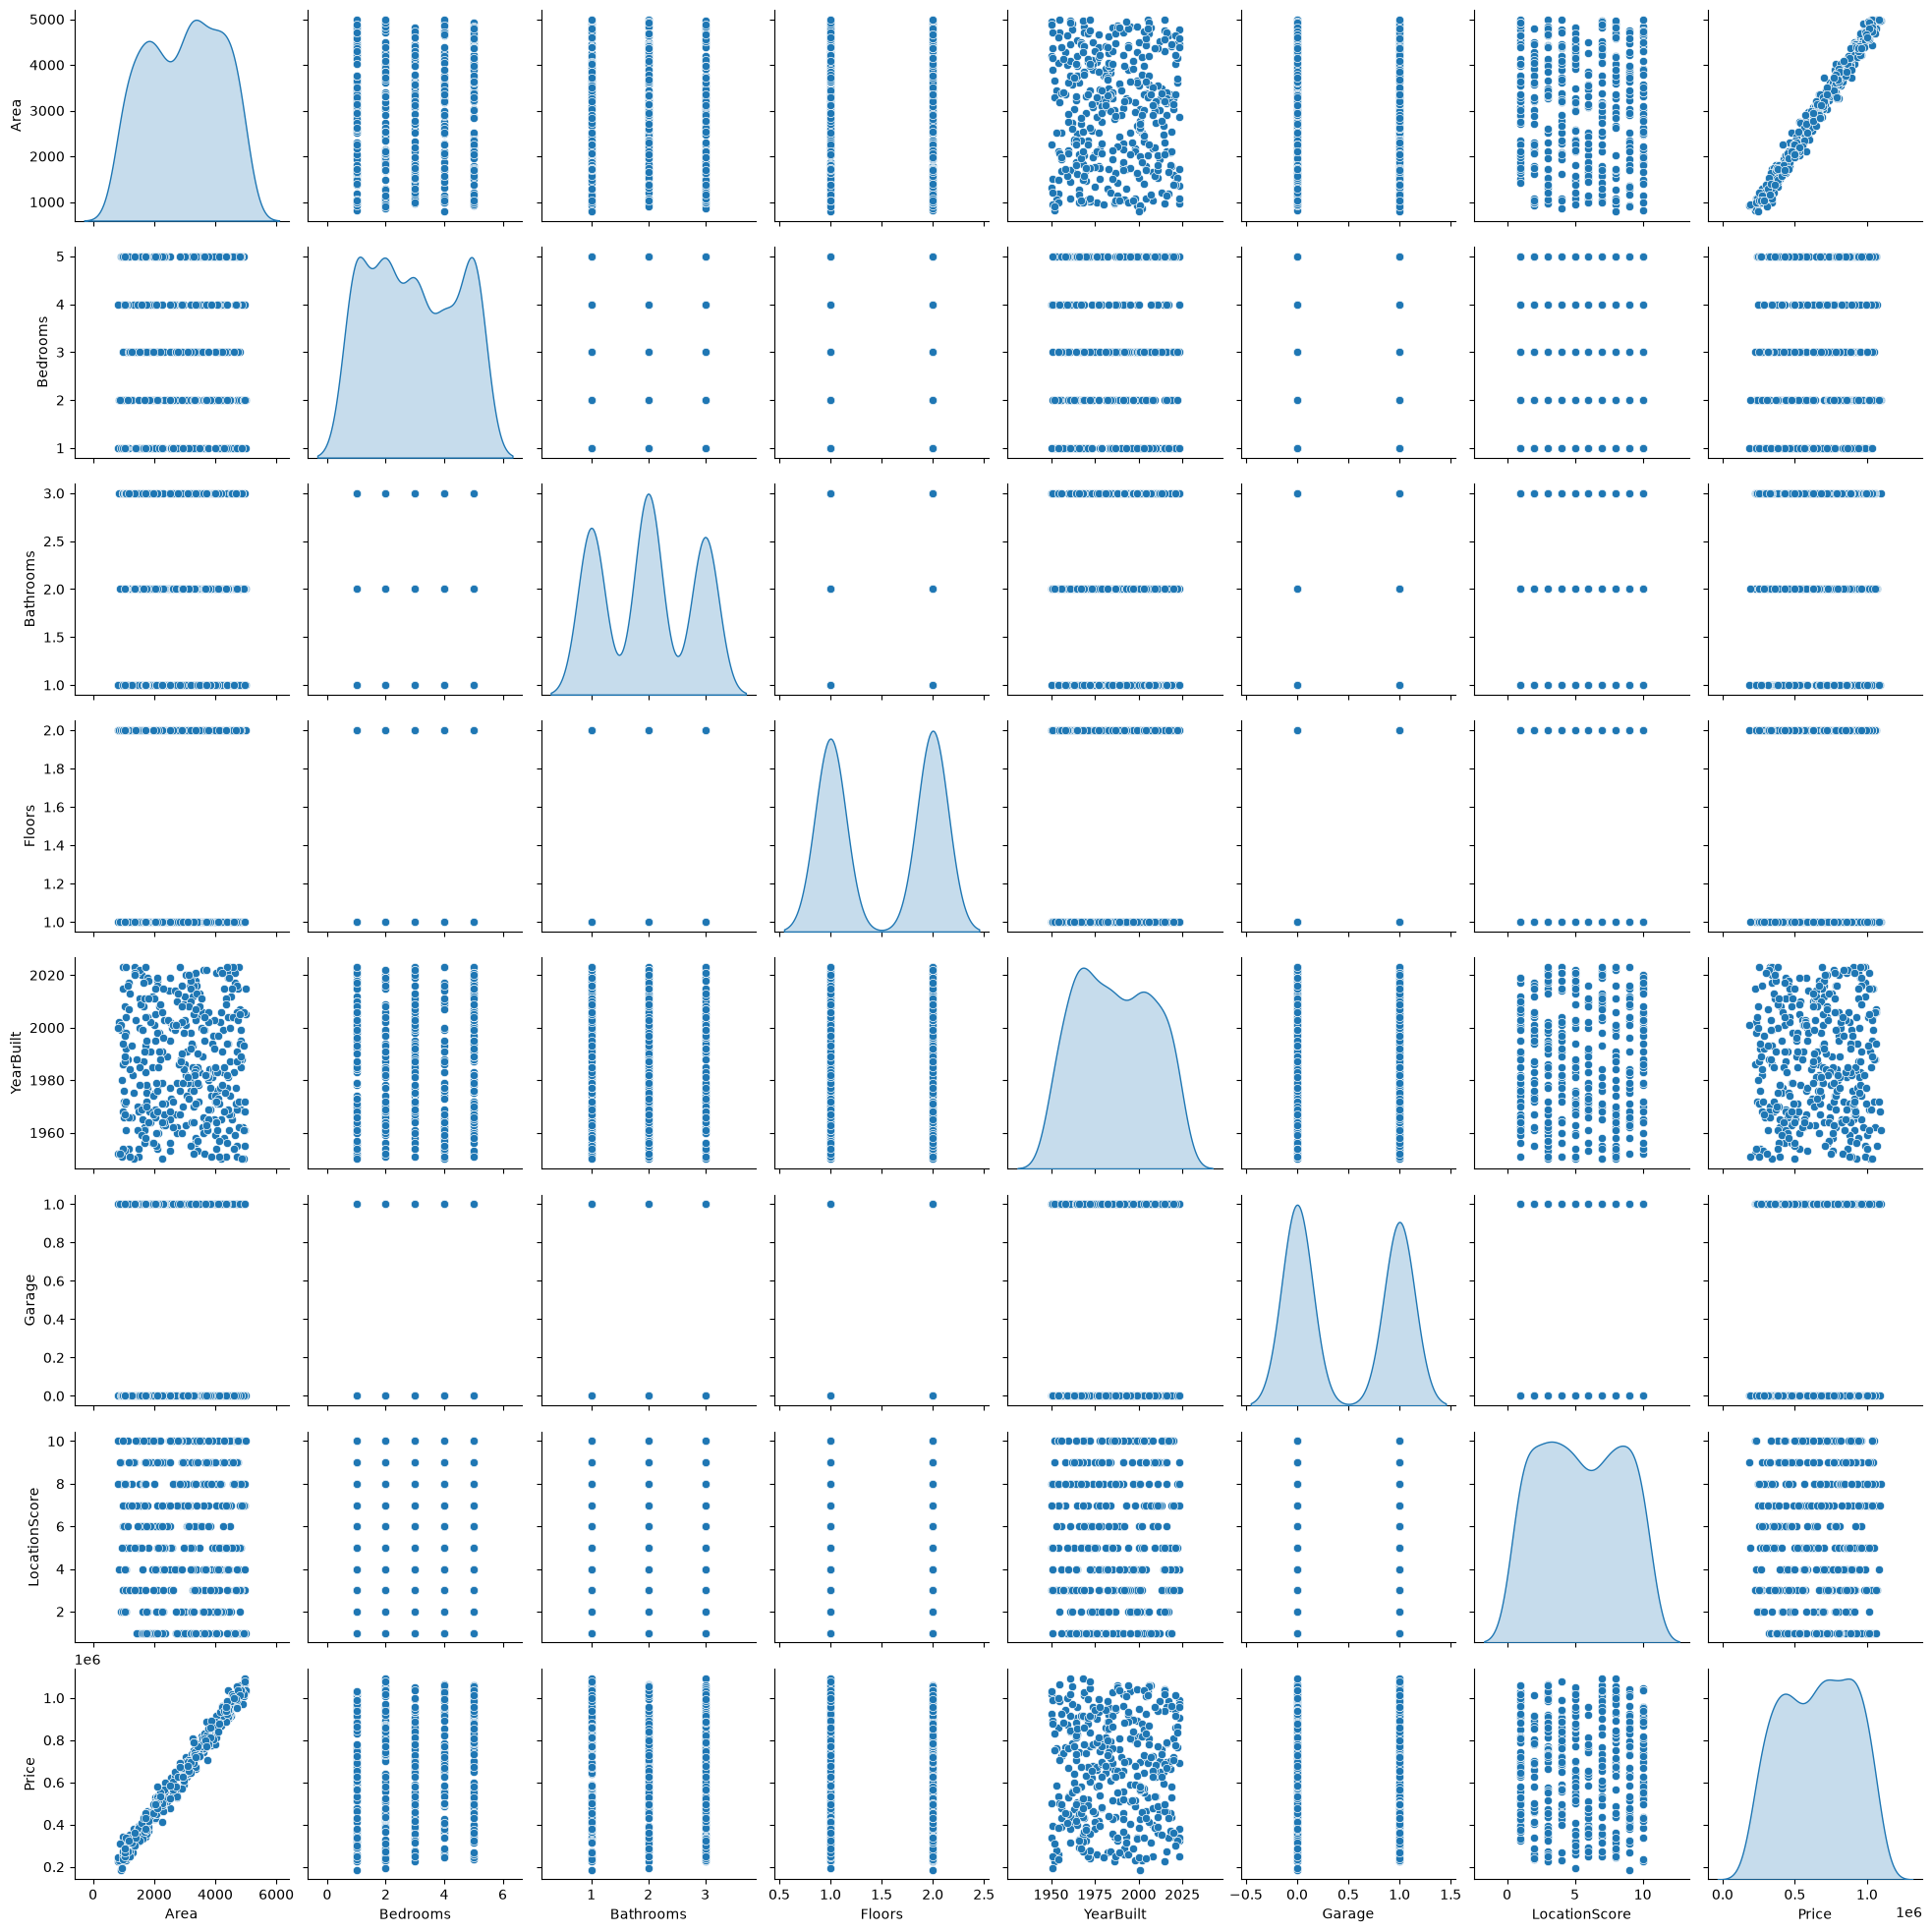

In [17]:
sns.pairplot(df.sample(400), diag_kind="kde")
plt.show()

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[241184.6 , 14253.08, 4162.47,..., 75.79, 7395.82, 8834.72]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.502e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[65.47,64.44,63.94,...,62.53,61.68,61.34]"


In [31]:
y_pred = model.predict(X_test)
# y_pred = model.predict([[2200, 3, 2, 1, 2010, 1, 7]])
# print(y_pred)

In [26]:
def house_prediction():
    print("\n Enter The House Features To Get Price: ")

    area = float(input("Area (sq ft): "))
    bedrooms = int(input("Bedrooms (1-5): "))
    bathrooms = int(input("Bathdrooms (1-3): "))
    floors = int(input("Floors (1-2): "))
    year = int(input("Year Build (1950-2023): "))
    garage = int(input("Garage (1- Yes, 2- No): "))
    loaction = int(input("Loaction Score (1-10): "))

    user_input = pd.DataFrame([[area, bedrooms, bathrooms, floors, year, garage, loaction]], columns = x.columns)

    user_scaled = scaler.transform(user_input)

    pre_prc = model.predict(user_scaled)[0]

    print(f"\n Predicted price: $ {pre_prc:,.0f}")

house_prediction()


 Enter The House Features To Get Price: 

 Predicted price: $ 514,791


In [35]:
# y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

MSE: 588697225.8136497
R^2 Score: 0.9899136812167135


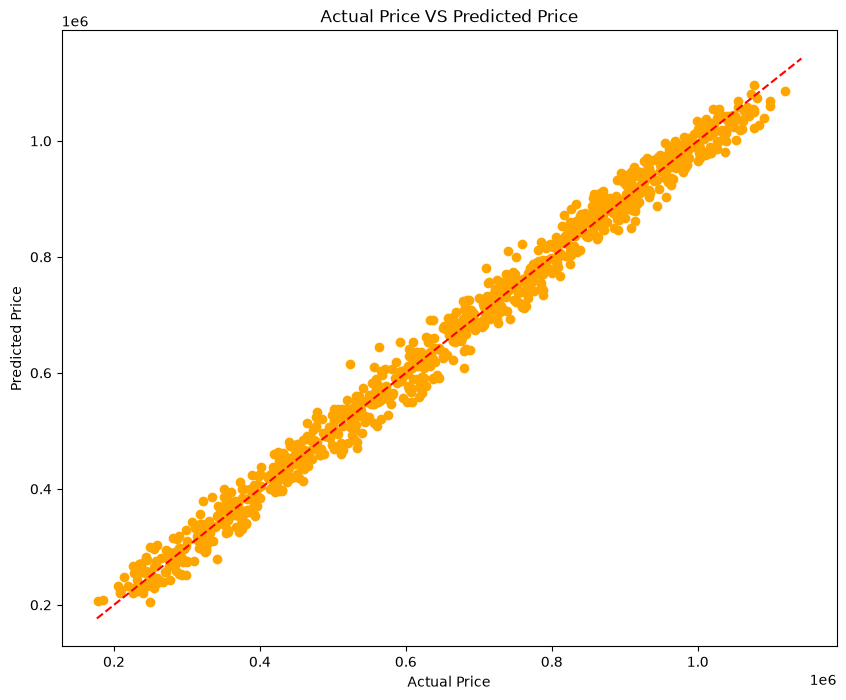

In [30]:
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred, alpha = 1, color = "orange")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price VS Predicted Price")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.show()